# 07 — RNA-RNA Interaction Basics

## Learning objectives

By the end of this notebook you will be able to:

- Fold **two interacting RNA strands** as a single fold compound using the
  `&`-separated sequence convention, and interpret the resulting dot-bracket
  structure as *intramolecular* and *intermolecular* base pairs.
- Compute an **interaction free energy** $\Delta\Delta G$ that quantifies how
  favorable binding is, relative to the two strands folding independently.
- Distinguish **RNAduplex-style** intermolecular-only structures
  (`RNA.duplexfold`) from full **RNAcofold-style** structures that allow each
  strand to keep its own intramolecular pairs.
- Recognize when a binding partner *disrupts* an existing structure versus
  when it *coexists* alongside it — and how a sweep over oligo length reveals
  a length threshold for productive binding.

**Prerequisites**: [02_mfe_folding.ipynb](02_mfe_folding.ipynb) (MFE folding
and energy interpretation) and [03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
(partition function and base-pair probabilities — used again here for an
intermolecular pairing heatmap).


## 1. Introduction & motivation

So far, every notebook has folded a **single** RNA molecule. But RNA biology
is full of *two-molecule* interactions: a microRNA binding its target mRNA, an
antisense oligonucleotide designed to silence a gene, two strands of a
riboswitch's terminator/anti-terminator, or simply two complementary primers.
In each case, the question is the same one we've asked all along — "what's
the lowest-free-energy structure?" — but now the structure can include base
pairs **between** two different strands as well as **within** each strand.

ViennaRNA handles this elegantly: concatenate the two sequences with an `&`
separator and fold the result as usual. The nearest-neighbor model (notebook
2) and partition function (notebook 3) work exactly as before; the only new
ingredient is that base pairs are now allowed to cross the strand boundary.

**Roadmap**: theory first (the `&` convention, cut points, and the
interaction free energy $\Delta\Delta G$), then three worked examples — a
short oligo that **disrupts** a target's hairpin by binding it directly, a
second oligo that **coexists** alongside an unrelated hairpin, and the
ensemble (partition function) view of intermolecular pairing — followed by a
case study sweeping oligo length to find the threshold for productive binding.


## 2. Theoretical background

### 2.1 Two strands, one fold compound

Given two sequences $x^{(1)}$ (length $n_1$) and $x^{(2)}$ (length $n_2$),
ViennaRNA represents the **complex** as a single sequence
$x = x^{(1)} \,\&\, x^{(2)}$ of length $n_1 + n_2$ (the `&` is a bookkeeping
marker, not a nucleotide — the reported structure has length $n_1+n_2$, with
position $n_1{+}1$ immediately following position $n_1$). Folding proceeds
exactly as in notebook 2:

$$
\Delta G(s \mid x) = \sum_{\ell} \Delta G_\ell, \qquad
s^* = \arg\min_{s \in \Omega(x)} \Delta G(s \mid x),
$$

except that $\Omega(x)$ now includes structures with base pairs $(i,j)$ where
$i \leq n_1 < j$ — an **intermolecular** pair — alongside ordinary
**intramolecular** pairs entirely within $x^{(1)}$ or entirely within
$x^{(2)}$.

### 2.2 Interaction free energy $\Delta\Delta G$

To ask "how favorable is binding, on top of whatever each strand does on its
own?", compare the complex's MFE to the sum of each strand's *own* MFE:

$$
\Delta\Delta G \;=\; \Delta G\big(x^{(1)} \,\&\, x^{(2)}\big) \;-\; \Delta G\big(x^{(1)}\big) \;-\; \Delta G\big(x^{(2)}\big).
$$

$\Delta\Delta G < 0$ means the complex is more stable than the two strands
apart — binding is thermodynamically favorable. $\Delta\Delta G \geq 0$ means
forming the complex gains nothing (or costs something) relative to each
strand folding independently; the MFE of the complex will then simply be the
two strands' independent structures side by side, with little or no
cross-strand pairing.

### 2.3 RNAcofold vs. RNAduplex

There are two complementary views of a two-strand system:

- **RNAcofold-style** (`RNA.fold_compound("seq1&seq2")`, `.mfe()`): the *full*
  MFE over all structures — intramolecular pairs in either strand, plus any
  intermolecular pairs. This is what you want if either strand might keep some
  of its own structure.
- **RNAduplex-style** (`RNA.duplexfold(seq1, seq2)`): restricted to
  **intermolecular pairs only** — no intramolecular structure is considered at
  all. This models a "pure hybridization" view (e.g. of two short,
  largely-unstructured oligos) and is much faster for long sequences since it
  doesn't need the full 2D dynamic-programming matrix.

### 2.4 Theory-to-API map

| Concept | ViennaRNA API |
| :--- | :--- |
| Full MFE of a two-strand complex | `RNA.fold_compound("seq1&seq2")`, then `.mfe()` |
| Partition function / bpp of a complex | same fold compound, then `.pf()`, `.bpp()` (notebook 3) |
| Intermolecular-only duplex (RNAduplex) | `RNA.duplexfold(seq1, seq2)` $\to$ `.structure`, `.energy` |
| Suboptimal duplex binding sites | `RNA.duplex_subopt(seq1, seq2, delta1, delta2)` |
| Interaction free energy $\Delta\Delta G$ | `mfe(complex) - mfe(seq1) - mfe(seq2)` (compute manually) |

The `&` character is only used when *constructing* the input sequence; the
returned dot-bracket structure has length $n_1+n_2$ with no `&` in it (each
position simply continues counting from strand 1 into strand 2).


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def draw_complex(ax, seq1, seq2, structure, title):
    '''Draw a two-strand complex with forgi.

    forgi's dot-bracket parser does not understand the '&' multi-strand
    separator used by RNAcofold's *input*, and its MFE *output* structure has
    no '&' at all -- so we draw the concatenated sequence as one continuous
    chain. For a complex this draws a single (possibly misleading) backbone
    bond across the strand junction, but the base-pairing pattern itself
    -- the part we care about -- is rendered correctly.
    '''
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq1 + seq2)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()


def interaction_ddg(seq1, seq2):
    '''Return (complex_structure, complex_mfe, ddg) for two interacting strands.'''
    e1 = RNA.fold_compound(seq1).mfe()[1]
    e2 = RNA.fold_compound(seq2).mfe()[1]
    structure, mfe = RNA.fold_compound(seq1 + "&" + seq2).mfe()
    return structure, mfe, mfe - (e1 + e2)


## 3. Worked example 1 — an antisense oligo that disrupts a hairpin

Take a short hairpin-forming target, `GGGGAAACCCC` (a 4-bp stem around a 3-nt
loop), and a 7-nt oligo, `UUUCCCC`, that is the **exact reverse complement**
of the target's 5' arm and loop (`GGGGAAA`). Folded together, can the oligo
out-compete the target's own hairpin?


In [2]:
target_1 = "GGGGAAACCCC"
oligo_1 = "UUUCCCC"

structure_t1, mfe_t1 = RNA.fold_compound(target_1).mfe()
structure_o1, mfe_o1 = RNA.fold_compound(oligo_1).mfe()
structure_c1, mfe_c1, ddg_1 = interaction_ddg(target_1, oligo_1)

print(f"Target alone:   {structure_t1}  ({mfe_t1:.2f} kcal/mol)")
print(f"Oligo alone:    {structure_o1}  ({mfe_o1:.2f} kcal/mol)")
print(f"Complex:        {structure_c1}  ({mfe_c1:.2f} kcal/mol)")
print(f"Interaction ddG: {ddg_1:.2f} kcal/mol")


Target alone:   ((((...))))  (-4.50 kcal/mol)
Oligo alone:    .......  (0.00 kcal/mol)
Complex:        (((((((....)))))))  (-10.00 kcal/mol)
Interaction ddG: -5.50 kcal/mol


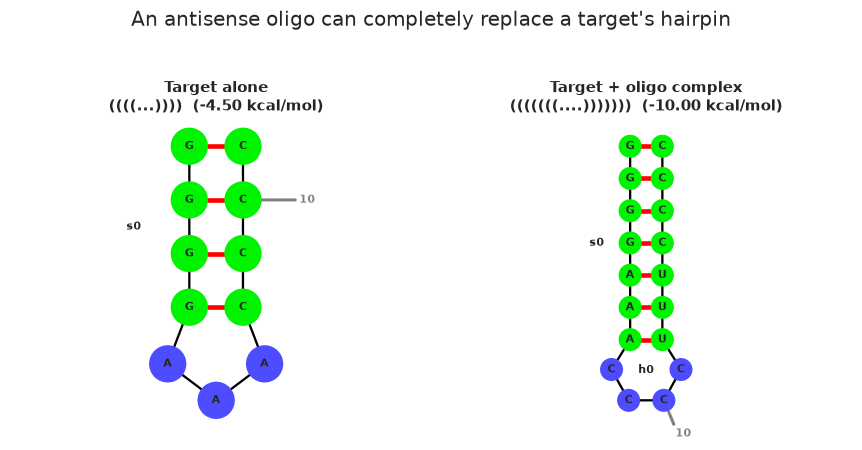

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_complex(axes[0], target_1, "", structure_t1,
             f"Target alone\n{structure_t1}  ({mfe_t1:.2f} kcal/mol)")
draw_complex(axes[1], target_1, oligo_1, structure_c1,
             f"Target + oligo complex\n{structure_c1}  ({mfe_c1:.2f} kcal/mol)")
fig.suptitle("An antisense oligo can completely replace a target's hairpin", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: on its own, the target folds into its 4-bp
hairpin (-4.5 kcal/mol); the 7-nt oligo alone has no stable structure
(0.0 kcal/mol — too short to form anything on its own). But together, the
oligo's full length pairs with the target's 5' arm and loop, **completely
replacing** the hairpin with a 7-bp intermolecular duplex (leaving the
target's `CCCC` tail unpaired). The interaction free energy
$\Delta\Delta G = -5.5$ kcal/mol confirms this is strongly favorable — the new
duplex is far more stable than the original hairpin plus an unfolded oligo.


## 4. Worked example 2 — an oligo that coexists with an unrelated hairpin

Now build a target with **two** independent hairpin-forming regions, separated
by a short linker: `GGGGAAACCCC` (hairpin 1) + `AAA` (linker) + `CCCCAAAGGGG`
(hairpin 2). Design an 7-nt oligo, `UUUGGGG`, complementary only to hairpin
2's 5' arm and loop. Will binding this oligo disturb hairpin 1, which it has
no complementarity to at all?


In [4]:
target_2 = "GGGGAAACCCC" + "AAA" + "CCCCAAAGGGG"
oligo_2 = "UUUGGGG"

structure_t2, mfe_t2 = RNA.fold_compound(target_2).mfe()
structure_o2, mfe_o2 = RNA.fold_compound(oligo_2).mfe()
structure_c2, mfe_c2, ddg_2 = interaction_ddg(target_2, oligo_2)

print(f"Target alone:   {structure_t2}  ({mfe_t2:.2f} kcal/mol)")
print(f"Oligo alone:    {structure_o2}  ({mfe_o2:.2f} kcal/mol)")
print(f"Complex:        {structure_c2}  ({mfe_c2:.2f} kcal/mol)")
print(f"Interaction ddG: {ddg_2:.2f} kcal/mol")


Target alone:   ((((...))))...((((...))))  (-11.20 kcal/mol)
Oligo alone:    .......  (0.00 kcal/mol)
Complex:        ((((...))))...(((((((....)))))))  (-16.70 kcal/mol)
Interaction ddG: -5.50 kcal/mol


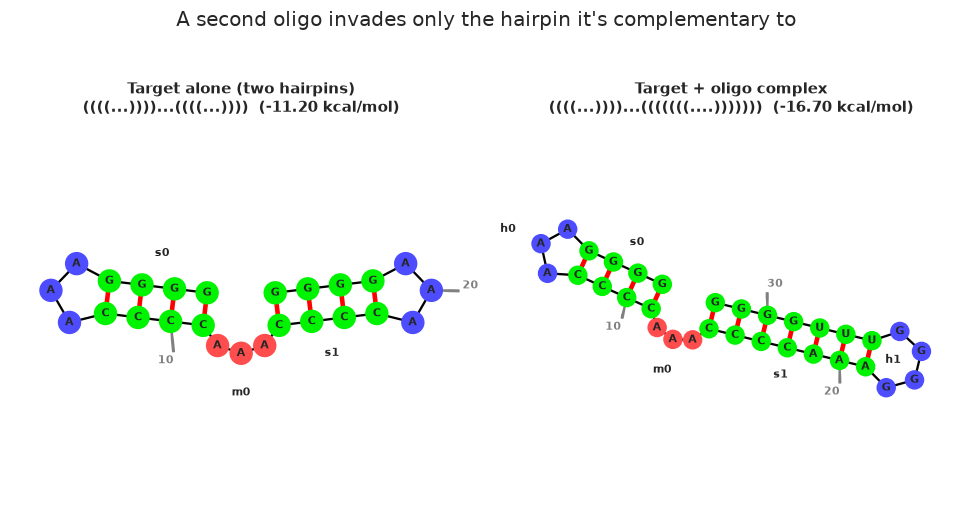

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
draw_complex(axes[0], target_2, "", structure_t2,
             f"Target alone (two hairpins)\n{structure_t2}  ({mfe_t2:.2f} kcal/mol)")
draw_complex(axes[1], target_2, oligo_2, structure_c2,
             f"Target + oligo complex\n{structure_c2}  ({mfe_c2:.2f} kcal/mol)")
fig.suptitle("A second oligo invades only the hairpin it's complementary to", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: hairpin 1 (`((((...))))`, the first 11
positions) is **identical** in the target-alone and complex structures — the
oligo has no complementarity there, so it simply doesn't participate. Hairpin
2, however, is replaced by a 7-bp duplex with the oligo, exactly as in Section
3. The interaction free energy ($-5.5$ kcal/mol, the same magnitude as Section
3) reflects only the *local* invasion of hairpin 2 — hairpin 1 contributes
identically to both the target-alone and complex energies and cancels out of
$\Delta\Delta G$. **Binding is local**: an oligo only competes with the
structure in the region it's complementary to.


## 5. Worked example 3 — the ensemble view: intermolecular base-pair probabilities

As in notebook 3, the MFE structure is only the *single most likely*
structure. Compute the partition function for the Section 3 complex and look
at the **intermolecular** base-pair probabilities — how confident is the
ensemble that the oligo is bound, position by position?


In [6]:
fc1 = RNA.fold_compound(target_1 + "&" + oligo_1)
mfe_struct, mfe_e = fc1.mfe()
fc1.exp_params_rescale(mfe_e)
pf_struct, pf_e = fc1.pf()
bpp = np.array(fc1.bpp())

n1, n2 = len(target_1), len(oligo_1)
print(f"MFE structure: {mfe_struct}  ({mfe_e:.2f})")
print(f"Ensemble free energy: {pf_e:.2f}")
print("\nIntermolecular base-pair probabilities (target position, oligo position):")
for i in range(1, n1 + 1):
    for j in range(n1 + 1, n1 + n2 + 1):
        if bpp[i, j] > 0.01:
            print(f"  target[{i}] -- oligo[{j - n1}] : p = {bpp[i, j]:.3f}")


MFE structure: (((((((....)))))))  (-10.00)
Ensemble free energy: -10.33

Intermolecular base-pair probabilities (target position, oligo position):
  target[1] -- oligo[6] : p = 0.010
  target[1] -- oligo[7] : p = 0.966
  target[2] -- oligo[5] : p = 0.010
  target[2] -- oligo[6] : p = 0.990
  target[3] -- oligo[4] : p = 0.010
  target[3] -- oligo[5] : p = 0.990
  target[4] -- oligo[3] : p = 0.010
  target[4] -- oligo[4] : p = 0.990
  target[5] -- oligo[2] : p = 0.010
  target[5] -- oligo[3] : p = 0.980
  target[6] -- oligo[2] : p = 0.907
  target[7] -- oligo[1] : p = 0.597


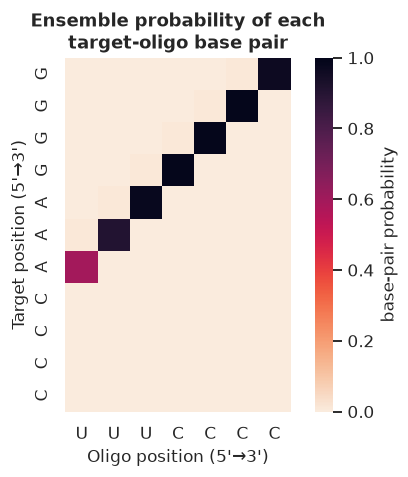

In [7]:
# Build a target-x-oligo probability matrix for a heatmap.
inter_bpp = np.zeros((n1, n2))
for i in range(1, n1 + 1):
    for j in range(n1 + 1, n1 + n2 + 1):
        inter_bpp[i - 1, j - n1 - 1] = bpp[i, j]

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(inter_bpp, ax=ax, cmap="rocket_r", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "base-pair probability"},
            xticklabels=list(oligo_1), yticklabels=list(target_1))
ax.set_xlabel("Oligo position (5'→3')")
ax.set_ylabel("Target position (5'→3')")
ax.set_title("Ensemble probability of each\ntarget-oligo base pair")
fig.tight_layout()
plt.show()


**Reading the figure**: the diagonal band of near-1.0 probabilities
confirms the MFE pairing — every position of the oligo is, with $>95\%$
probability, paired to its designed target partner. There's essentially no
ensemble uncertainty here: with $\Delta\Delta G = -5.5$ kcal/mol, the bound
state dominates the ensemble almost completely (compare to notebook 3, where
a smaller energy gap produced much more spread-out probabilities).


## 6. Case study — how long does an oligo need to be?

Section 3's 7-nt oligo decisively won out over the target's hairpin. Would a
*shorter* oligo still bind productively? Sweep the oligo length from 3 to 9
nt — each oligo is the exact reverse complement of the target's first $k$
nucleotides — and track $\Delta\Delta G$.


In [8]:
def revcomp(seq):
    pairs = {"A": "U", "U": "A", "G": "C", "C": "G"}
    return "".join(pairs[b] for b in reversed(seq))


target_3 = "GGGGGGAAACCCCCC"  # 6-bp stem, 3-nt loop
structure_t3, mfe_t3 = RNA.fold_compound(target_3).mfe()

sweep_rows = []
for k in range(3, 10):
    oligo = revcomp(target_3[:k])
    structure_c, mfe_c, ddg = interaction_ddg(target_3, oligo)
    sweep_rows.append({"length": k, "oligo": oligo, "structure": structure_c, "ddg": ddg})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


,length,oligo,structure,ddg
0,3,CCC,((((((....)))).)).,3.000000
1,4,CCCC,((((((....))))..)).,2.800000
2,5,CCCCC,(((((..........))))),0.700001
3,6,CCCCCC,((((((.........)))))),-2.400000
4,7,UCCCCCC,(((((((........))))))),-4.000000
5,8,UUCCCCCC,((((((((.......)))))))),-4.900000
6,9,UUUCCCCCC,(((((((((......))))))))),-5.500000


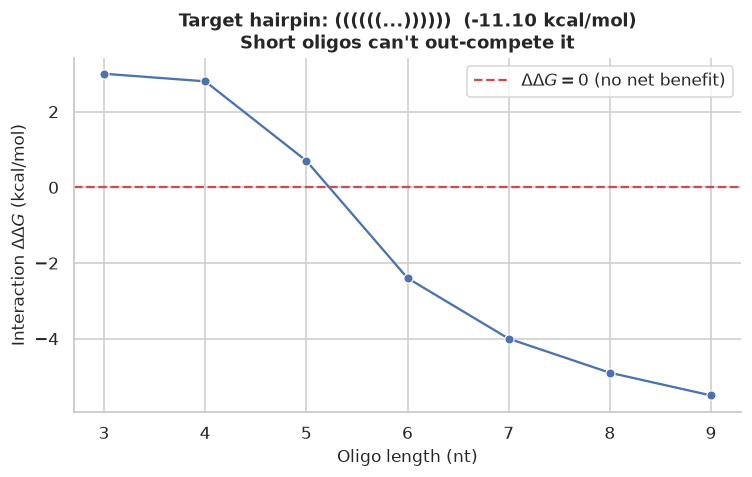

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=sweep_df, x="length", y="ddg", marker="o", color=PALETTE[0], ax=ax)
ax.axhline(0, color=PALETTE[3], ls="--", lw=1.5, label=r"$\Delta\Delta G = 0$ (no net benefit)")
ax.set_xlabel("Oligo length (nt)")
ax.set_ylabel(r"Interaction $\Delta\Delta G$ (kcal/mol)")
ax.set_title(f"Target hairpin: {structure_t3}  ({mfe_t3:.2f} kcal/mol)\nShort oligos can't out-compete it")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: for oligos shorter than the target's 6-bp
stem ($k \leq 5$), $\Delta\Delta G > 0$ — binding would *cost* free energy
relative to the hairpin staying intact, so the MFE complex simply keeps the
hairpin and leaves the short oligo unpaired (or only weakly engaged). Once the
oligo reaches the full stem length ($k=6$) and beyond, $\Delta\Delta G$ turns
negative and keeps improving — each additional base pair (plus the loop
nucleotides becoming available once the stem is replaced) adds further
stability. **There is a length threshold for productive binding**, set here by
the stability of the structure being displaced — a key consideration when
designing antisense oligos or siRNAs against structured targets.


## 7. Best practices and common pitfalls

- **The `&` is input-only.** `RNA.fold_compound("seq1&seq2")` accepts it to
  mark the strand boundary, but the returned structure string has length
  $n_1+n_2$ with *no* `&` — position $n_1{+}1$ is oligo position 1.
- **Always compute $\Delta\Delta G$ relative to each strand's own MFE**, not
  relative to zero. A complex MFE of $-10$ kcal/mol sounds great, but if one
  strand alone is already at $-9$ kcal/mol, binding only contributes $-1$
  kcal/mol.
- **`RNA.duplexfold` ignores intramolecular structure entirely** — useful for
  quick screening of many candidate oligos against a long target, but it can
  *overestimate* binding for targets whose region of interest is normally
  locked up in a stable intramolecular structure (compare to Section 6: a
  duplex-only view would predict the same duplex for every oligo length,
  missing the threshold effect entirely).
- **Binding is local** (Section 4) — an oligo's effect on $\Delta\Delta G$
  mostly reflects the structure it directly competes with, not the target's
  global fold. For large targets, focus on the local structural context of
  the binding site, not the whole-molecule MFE.
- **For genuinely long targets**, folding the full target with every candidate
  oligo via `fold_compound` is expensive; `RNA.duplexfold` or
  `RNA.duplex_subopt` (which scan for good intermolecular complementarity
  directly) scale much better as a first-pass filter.


## 8. Summary

- A two-strand complex is folded as one `fold_compound("seq1&seq2")`; the
  nearest-neighbor model and all downstream tools (MFE, `pf()`, `bpp()`) work
  unchanged, now allowing pairs across the strand boundary.
- **Interaction free energy** $\Delta\Delta G = \Delta G(\text{complex}) -
  \Delta G(\text{strand 1}) - \Delta G(\text{strand 2})$ quantifies whether
  binding is favorable, and by how much.
- Binding can **disrupt** a target's existing structure (Section 3),
  **coexist** alongside unrelated structure elsewhere (Section 4), or **fail
  to compete** with a stable enough structure (Section 6) — all depending on
  the local energetic balance.
- `RNA.duplexfold`/`RNA.duplex_subopt` give a faster, intermolecular-only
  (RNAduplex-style) view, useful for screening but blind to competition with
  intramolecular structure.

**Next**: [08_environment_effects.ipynb](08_environment_effects.ipynb) returns
to single-sequence folding and asks how **temperature and model parameters**
change everything we've computed so far.


## 9. Exercises

1. In Section 3, the oligo `UUUCCCC` is the exact reverse complement of
   `target_1[:7]`. Design an oligo that is the reverse complement of
   `target_1[4:]` (the 3' arm and loop) instead. Does it also disrupt the
   hairpin? Is $\Delta\Delta G$ similar?
2. In Section 6, the sweep used oligos complementary to the target's *5'* arm.
   Repeat the sweep using oligos complementary to the target's *3'* arm
   (`target_3[-k:]`, reverse-complemented). Is the length threshold the same?
   Should it be, given the hairpin's symmetry?
3. Use `RNA.duplex_subopt(target_2, oligo_2, 5, 5)` to find alternative binding
   sites for the Section 4 oligo. Does it find the same site as the full
   `fold_compound` MFE? What does it miss by not considering hairpin 1 at all?
